# [Decliner-SO] Reproduction de l'étude Décliner la science ouverte : de R à Python

Émilien SCHULTZ - PySHS - 18/05/2022 - modifié le 03/06/2022 - modifié le 19/07/2022

Célya GRUSON-DANIEL modifié le 21/06/22 (ajout contextualisation initiale) - modifié le 20/07/2022

## 1. Contexte de l'étude « Décliner la science ouverte »

L’étude Décliner la science ouverte (Decliner-SO) a été réalisée dans le cadre de la mission « [Réussir l’appropriation de la science ouverte](https://www.ouvrirlascience.fr/reussir-lappropriation-de-la-science-ouverte/?menu=1) » pour le Comité pour la science ouverte (CoSO). 
Elle constitue une enquête de terrain auprès de professionnel·le·s de la recherche dans diverses disciplines pour :
- mieux appréhender les pratiques associées aux données et leurs évolutions avec la science ouverte ;
- comprendre les facteurs différenciant ces pratiques (discipline, démarche de recherche, etc.) ;
- apporter un accompagnement adapté aux besoins de différentes communautés de recherche.

L’étude réalisée s’est appuyée sur des méthodes mixtes avec deux premières phases qualitatives comprenant des entretiens (exploratoires, observation des pratiques), des focus group, et une journée d’étude. À la suite, une phase quantitative a été réalisée s’appuyant sur la conception, diffusion et analyse d’un questionnaire auprès des enseignant·e-chercheur·e.s et des personnels de la recherche en France (plus de 400 réponses). L’étude s’est finalisée par le croisement des résultats de ces phases et une démarche design pour faciliter l’appropriation du contenu.


### Résumé synthétique de la méthodologie d’analyse du questionnaire : 

0. Exportation des résultats (.csv) du questionnaire réalisé sur limesurvey.
    - réponses complètes seulement (429 réponses)
1. Préparation des données
    - enlever les champs libre pour empêcher l'identification
    - recoder deux variables libres identifiables
2. Analyse statistique descriptive univariée
    - tris à plat
    - tris croisés
3. Analyse statistique multivariée
    - ACM HCPC séparant deux dimensions (pratiques « open science » et contexte de recherche)

L'analyse a été réalisée par `Claire Lemercier (CNRS/CSO-Sciences Po)` avec l'utilisation de Libre Office Calc pour la préparation des données puis de R pour les analyses statistiques. Une partie initiale des recodages a été réalisé sous R, introduisant potentiellement des erreurs de manipulation. Ce recodage a permis de stabiliser des catégories qui sont utilisées ici.

## 2. Cadrage du projet de reproduction des résultats

### Objectifs

Dans une démarche de reproductibilité, un projet de reproduction des résultats a été réalisé par `Emilien Schultz (Sciences Po ; médialab)` consistant à : 

- repartir des données brutes et tenter la reproduction de l'ensemble des traitements effectués (structuration, mise en forme des données, analyses statistiques en utilisant Python (analyse initiale en R). 
- s'aider de l'ensemble des contenus produits (fichiers de données bruts et intermédiaires,scripts en R et sa documentation, note méthodologique, rapports et résumés des résultats finaux, graphiques).

Le projet a permis plus largement d'entamer une réflexion sur l'autonomie de la reproduction des traitements et les orientations et pratiques épistémologiques que reflètent l'utilisation de R et de python et des bibliothèques spécialisées développées dans certaines communautés de recherche (FactoMineR par exemple). 

### Synthèse 

De ce projet, il en ressort : 
- une possibilité de reproduire les principaux traitements réalisés avec des itérations qui ont été nécessaires avec l'équipe projet pour clarifier/préciser certains points méthodologiques.
- la nécessité de développer de nouvelles fonctions pour être au plus proche des bibliothèques créees sur R faisant ressortir des choix épistémologiques ancrées et (invisibilisés) dans les outils employés par les communautés
- la proposition d'une exploration interactive des données pour faciliter leur analyse au cours du projet 

**Un des résultats a d'ailleurs été le portage (partiel) de la fonction catdes de FactoMineR dans la bibliothèque [PySHS](https://github.com/emilienschultz/pyshs-bib)**

### Quelques limites :

- Des fonctions/outils spécifiques à R manquent à Python. Cela a conduit à recoder certaines fonctions, mais ce processus n'est pas encore aboutit. Les améliorations principales à faire concernent : 
    - la prise en compte de la pondération des données pour certains traitements, 
    - une différence numérique (minime) entre les résultats R et Python de la fonction catdes
- Des pratiques d'analyse bien que documentées nécessitant un temps important d'appropriation et de redécouverte. 

### Pistes futures pour le projet (travail encore en cours)

- une présentation du projet et des réflexions lors d'une session cocopyshs (mars 2023)
- un dialogue au plus long terme avec les équipes de développement des bibliothèques R pour comprendre quelques différences
- une amélioration des modules d'exploration interactive des données

## 3. Démarche générale de reproduction de l'étude

Trois grandes étapes ont été nécessaires :

1. reproduction du recodage pour produire un tableau identique
2. reproduction des analyses statistiques (classification)
3. visualisations et éléments diffusables (travail en cours)

La partie de reproduction du codage n'est pas traité dans ce notebook et a donné lieu à des échanges internes au projet. Dans ce projet, nous repartons des données brutes et nous déroulons l'analyse.

La note méthodolgique `2022-01_note-methodo-v0.1.pdf` et les scripts R ont été employés pour s'approprier les différents traitements réalisées.

### Quelques remarques

Journal des réflexions :

- identifier les principaux blocages : fonctions R spécifiques + interfaces interactives spécifiques
- script R bien expliqué sur les analyses, moins sur les recodages etc.
 - difficulté de lire la documentation R des fonctions spécifiques à FactoMineR (v test)
 - identifier correctement les dictionnaires de recodage qui a été un peu difficile : important de bien documenter les entités de recodage, les règles qui ont été appliquées, etc
- réflexion sur les widgets en cours -> quelle place donner à l'interactivité ?

Suite à la présentation du 18/05/22

- les widgets semblaient ne pas fonctionner sur le jupyterhub Inno3
- il y a quelques discordances encore dans le traitement des données
- **attention** la coloration des tableaux + widgets n'apparaissent pas sur une forge il faut exécuter le Notebook

Suite à la réunion du 19/07/22

- La différence de codage identifiée tient à quelques erreurs ponctuelles et à une règle non identifiée

## Chargement des bibliothèques utilisées

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#!pip install prince
import prince

!pip install pyshs --upgrade
import pyshs 

# Pour la gestion des widgets
import ipywidgets as widgets
from IPython.display import display,clear_output

# Enlever les warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Chargement des données brutes
data_brut = pd.read_csv("./data/2021_QSO_data-brut-diffusable.csv")

# Recodage des variables dans un fichier dédié
variables = pd.read_csv("./data/recodage_colonnes.csv")

# Filtrer les variables d'intérêt
f = pd.isnull(variables["variable enlevée dans QSO2"])
data = data_brut[variables[f]["brut"]]
data.columns = list(variables[f]["reco"])

In [3]:
# Recodage des variables
data["sexe"] = data["sexe"] #.fillna("NA")

reco = {"Autres Unix":"LinuxUnix","Linux":"LinuxUnix"}
data["sysOS"] = data["sysOS"].replace(reco)

reco = {'Nous sommes plus de 50 personnes':"11plus", 
        'Nous sommes entre 6 et 10 personnes':"6a10",
        'Nous sommes entre 2 et 5 personnes':"2a5", 
        'Je travaille seul.e':"seule",
        'Nous sommes entre 11 et 20 personnes':"11plus", 
        'Nous sommes entre 21 et 50 personnes':"11plus"}
data["tailleequipe"] = data["tailleequipe"].replace(reco)

reco = {'Plutôt satisfait':"plutotsat", 
        'Plutôt insatisfait':"insatisfait", 
        'Très satisfait':"tressat",
        'Ni satisfait, ni insatisfait':"nini", 
        #'Très insatisfait':"tressat"} ERREUR QUI A ETE FAITE DANS LE CODAGE INITIAL
        'Très insatisfait':"insatisfait"}
data["oksoutien"] = data["oksoutien"].replace(reco)

# Rajout de colonnes spécifiques

# Q224 sur les limites qui est un recodage de colonne (non précisé)
def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Un manque d’habitude de cette pratique dans les communautés de recherche (savoir faire, etc.)' in col:
        return "Oui"
    else:
        return "Non"
    
data["limite_habitude"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Une volonté de valoriser le travail effectué avant un partage pour garder un avantage compétitif.' in col:
        return "Oui"
    else:
        return "Non"
data["limite_valo"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Un doute sur la capacité de réutilisation des données par d’autres (contextualisation et documentation nécessaire).' in col:
        return "Oui"
    else:
        return "Non"
data["limite_doute"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Un temps trop important nécessaire à leur mise à disposition.' in col:
        return "Oui"
    else:
        return "Non"
data["limite_temps"] = data.apply(reco, axis=1)

def reco(l):
    col = list(l[["limite1","limite2","limite3","limite4"]])
    if 'Une peur de mésusage des données par les personnes les réutilisant.' in col:
        return "Oui"
    else:
        return "Non"
data["limite_mesusage"] = data.apply(reco, axis=1)

# Ajout de la variable fct_autre : oui si (fct_SI="Oui" OU fct_valo="Oui" OU fct_sciouv="Oui" OU fct_manag="Oui" OU fctcom="Oui")
data['fct_autre'] = data.apply(lambda x : "Oui" if "Oui" in [x["fct_SI"],x["fct_valo"],x["fct_sciouv"],x["fct_manag"],x["fct_com"]] else "Non",axis=1)

# Codage de colonnes intermédiaires des disciplines et de la pondération
data["dt"] = data["disc_dt"]=="Oui"
data["inf"] = data["disc_inf"]=="Oui"
data["lsh"] = data["disc_lsh"]=="Oui"
data["math"] = data["disc_math"]=="Oui"
data["pluri"] = data["disc_pluri"]=="Oui"
data["vie"] = data["disc_vie"]=="Oui"
data["inge"] = data["disc_inge"]=="Oui"
data["terre"] = data["disc_terre"]=="Oui"
data["matiere"] = data["disc_matiere"]=="Oui"

data["ST"] = (data["inf"] | data["math"] | data["vie"] | data["inge"] |data["matiere"]|data["terre"]|data["pluri"])&(~data["dt"])&(~data["lsh"])
data["LSH"] = (data["lsh"])&~data["dt"]&~data["inf"]&~data["math"]&~data["vie"]&~data["inge"]&~data["terre"]&~data["matiere"]
data["DE"] = (data["dt"])&~data["inf"]&~data["lsh"]&~data["math"]&~data["vie"]&~data["inge"]&~data["terre"]&~data["matiere"]
data["autre"] = ((~data["lsh"])&(~data["dt"])&(~data["inf"])&(~data["math"])&(~data["vie"])&(~data["inge"])&(~data["terre"])&(~data["matiere"]))|(data["ST"] & data["LSH"])|(data["ST"] & data["DE"])|(data["LSH"] & data["DE"])

#    ST = inf or math or vie or inge or matiere or terre or plur) and non dt and non lsh
#    LSH =  (lsh or pluri) and no dt and no inf and no math and no vie and no inge and no terre and no matiere
#    DE = (dt or pluri) and no inf and no lsh and no math and no vie and no inge and no terre and no matiere
#    AUTRE SINON

def reco(l):
    if l["autre"]:
        return "autre"
    if l["LSH"]:
        return "LSH"
    if l["DE"]:
        return "DE"
    if l["ST"]:
        return "ST"
    return "autre"
    

data["disc_pour_ponde"] = data.apply(reco,axis=1) #petite différence encore A REGLER

# Ajout de la pondération
poids = {"autre":1,"DE":3.4,"LSH":0.6,"ST":1.4}
data["poids"] = data["disc_pour_ponde"].replace(poids)

# Recodage des spécialités : déjà fait dans l'anonymisation
#dictionnaire_specialites = {}
#for i,j in pd.read_csv("../Data/recodage_specialites.csv").iterrows():
#    if pd.notnull(j["specialite"]):
#        dictionnaire_specialites[j["specialite"]] = j["recodage_specialite"] 
#data["specialite"] = data["specialite"].replace(dictionnaire_specialites)

# Recodage structures : déjà fait dans l'anonymisation
#dictionnaire_structure = {}
#for i,j in pd.read_csv("../Data/recodage_structure.csv").iterrows():
#    if pd.notnull(j["structure"]):
#        dictionnaire_structure[j["structure"]] = j["recodage_structure"] 
#data["structure"] = data["structure"].replace(dictionnaire_structure)

# Recodage statut
reco = {'Fonctionnaire ou assimilé': "fonct", 'En CDD': "CDD", 'Contrat doctoral': "doct",
        'Autre (précisez en commentaire)': "autre", 'En CDI': "CDI", 
        'Travailleur/travailleuse indépendante': "autre"}
data["statut"] = data["statut"].replace(reco).replace({"ne souhaite pas le dire":None})

# Recodage temps
reco = {'1': "moins", '2': "moins", 'M': "moins", '3': "plus", 'P': "plus"}
liste_var = ['temps_collecte', 'temps_numeriser', 'temps_corpus', 'temps_nettoyer', 'temps_structurer',
          'temps_analyser','temps_modeliser', 'temps_visu', 'temps_qualifier', 'temps_archiver', 
          'temps_qualite', 'temps_disporech', 'temps_com','temps_formation']
for c in liste_var:
    data[c] = data[c].replace(reco)

d_test = data.copy()
    
# Suppression des colonnes "intermédiaites"
data=data.drop(columns=["dt","inf","lsh","math","pluri","vie","inge","autre",
                        "terre","matiere","ST","LSH","DE",
                        "limite1","limite2","limite3","limite4","fct_manag",
                        "fct_com","fct_sciouv","fct_valo","fct_SI","fct_jur"])

## Analyse statistique des données


In [4]:
data.head()

,ID,envir_labo,envir_clinique,envir_terrain,envir_bibarchives,envir_modele,envir_theoredac,terme_corpus,terme_ressources,terme_valeurs,...,specialite,sexe,limite_habitude,limite_valo,limite_doute,limite_temps,limite_mesusage,fct_autre,disc_pour_ponde,poids
0,14,Oui,Non,Non,Non,Non,Oui,Oui,Non,Non,...,NaN,NaN,Oui,Oui,Non,Non,Non,Non,LSH,0.6
1,15,Oui,Non,Non,Non,Non,Non,Non,Non,Non,...,NaN,Autre,Non,Oui,Oui,Non,Oui,Non,DE,3.4
2,16,Non,Oui,Non,Non,Non,Non,Non,Oui,Non,...,NaN,Un homme,Non,Oui,Oui,Non,Non,Non,LSH,0.6
3,29,Non,Non,Oui,Oui,Non,Oui,Oui,Non,Non,...,autre,Une femme,Non,Oui,Oui,Non,Non,Non,LSH,0.6
4,94,Non,Non,Oui,Oui,Oui,Oui,Oui,Non,Non,...,histoire,Une femme,Non,Non,Oui,Non,Oui,Non,LSH,0.6


### Analyses univariées

In [5]:
pyshs.tri_a_plat(data,"envir_labo","poids")

,Effectif redressé,Pourcentage (%)
Non,280.8,64.6
Oui,153.8,35.4
Total,434.6,100.0


In [6]:
pyshs.tri_a_plat(data,"terme_valeurs","poids")

,Effectif redressé,Pourcentage (%)
Non,344.6,79.3
Oui,90.0,20.7
Total,434.6,100.0


Faire les tri à plats d'intérêt

#### Aller vers l'interactivité : exemple

(les widgets ne s'affichent que si le Notebook est exécuté)

In [7]:
a = list(data.columns)
w = widgets.Dropdown(
    options=a,
    value=a[1],
    description='Variable : ',
    disabled=False,)

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        clear_output()
        #print("Variable : ",w.value)
        t = pyshs.tri_a_plat(data,w.value,"poids")
        display(t)
        #t.to_csv(f"{w.value}.csv")
        display(w)

w.observe(on_change)
display(w)

Dropdown(description='Variable : ', index=1, options=('ID', 'envir_labo', 'envir_clinique', 'envir_terrain', '…

Possibilité de rajouter une sauvegarde automatique dans un fichier, etc.

#### Construction de tri à plats "plus complexes"

Construire des tableaux "à façon".

Par exemple remarquer que les questions ont été codées par "bloc" et que l'on voudrait un tableau par bloc

In [8]:
blocs = set([i.split("_")[0] for i in data.columns if "_" in i])

corpus_tap = {}

for b in blocs:
    col = [i for i in data.columns if b+"_" in i]
    t = {i:pyshs.tri_a_plat(data.fillna("NA"),i,"poids")["Pourcentage (%)"] for i in col}
    t = pd.concat(t,axis=1)    
    corpus_tap[b] = t
corpus_tap.keys()

dict_keys(['wavec', 'oblig', 'produit', 'envir', 'mettredispo', 'source', 'plus', 'collab', 'temps', 'conserv', 'terme', 'dispo', 'quali', 'aidequi', 'outil', 'soutien', 'log', 'aide', 'limite', 'fct', 'disc', 'forma'])

In [9]:
corpus_tap["collab"]

,collab_cahier,collab_bdd,collab_dosspartage,collab_redacpartage,collab_codepartage,collab_wiki,collab_gestionproj,collab_seul
Non,80.6,78.8,21.1,60.1,79.7,86.0,87.0,81.8
Oui,19.4,21.2,78.9,39.9,20.3,14.0,13.0,18.2
Total,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


#### Production d'une petite visualisation

<AxesSubplot:>

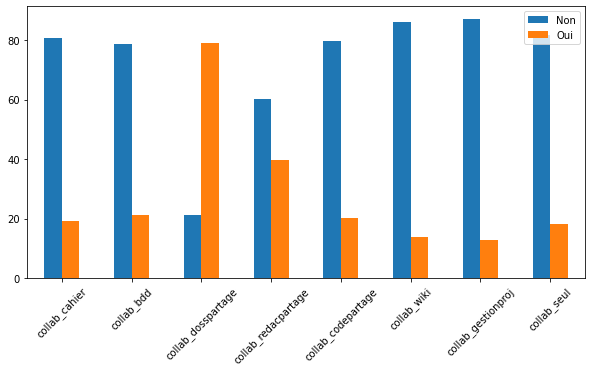

In [10]:
corpus_tap["collab"].drop("Total").T.plot(kind="bar",figsize=(10,5),rot=45)

Visualisation plus finalisées (similaire au rapport, à finaliser si besoin)

In [11]:
d = ["fct_perma","fct_nonperma","fct_IT","fct_bib","fct_autre"]

values = {i:pyshs.tri_a_plat(data,i,"poids")["Pourcentage (%)"].loc["Oui"] for i in d}

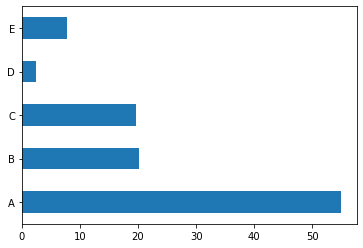

In [12]:

# Construction d'un tableau "à façon"
s = pd.Series({i:pyshs.tri_a_plat(data,i,"poids")["Pourcentage (%)"].loc["Oui"] for i in d})

# Base avec Pandas
ax = s.plot(kind="barh")

# Options avec Matplotlib
ax.set_yticklabels(["A","B","C","D","E"])
plt.savefig("fig1.pdf",bbox_inches="tight")

<AxesSubplot:>

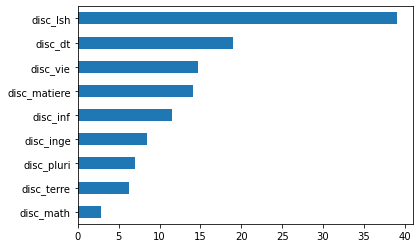

In [13]:
d = [i for i in data.columns if "disc_" in i if i!="disc_pour_ponde"]
s = pd.Series({i:pyshs.tri_a_plat(data,i,"poids")["Pourcentage (%)"].loc["Oui"] for i in d})
s.sort_values().plot(kind="barh")

Text(0.5, 1.0, 'Fonctions des répondants (pondéré)')

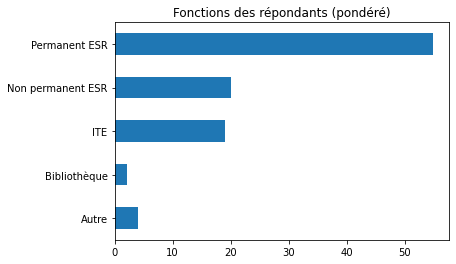

In [14]:
d = ["fct_perma","fct_nonperma","fct_IT","fct_bib","fct_autre","poids"]
data[d].replace({"Oui":1,"Non":0})

def fonction(l):
    if l["fct_perma"]=="Oui":
        return "Permanent ESR"
    if l["fct_nonperma"]=="Oui":
        return "Non permanent ESR"
    if l["fct_IT"]=="Oui":
        return "ITE"
    if l["fct_bib"]=="Oui":
        return "Bibliothèque"
    if l["fct_autre"]:
        return "Autre"
data["fonction"] = data.apply(fonction,axis=1)

pyshs.tri_a_plat(data,"fonction","poids")["Pourcentage (%)"].drop("Total").plot(kind="barh")
plt.title("Fonctions des répondants (pondéré)")

Avec pondération

### Analyse bivariée

L'enjeu est de définir les variables à croiser

Dans R utilisation massive d'une fonction "automatique" catdes -> c'est une philosophie

#### Faire un tableau à la main

In [15]:
tab = pyshs.tableau_croise(data,"reprofam","envir_clinique","poids")
tab.to_csv("Tableau.csv")
tab

,Non,Oui,Total
Assez,166.0 (97.3%),4.6 (2.7%),170.6 (100%)
Pas du tout,43.8 (98.6%),0.6 (1.4%),44.4 (100%)
Peu,62.8 (100.0%),0.0 (0.0%),62.8 (100%)
Tout à fait,144.4 (92.1%),12.4 (7.9%),156.8 (100%)
Total,417.0 (96.0%),17.6 (4.0%),434.6 (100%)


In [16]:
pd.crosstab(data["reprofam"],data["envir_clinique"])

envir_clinique,Non,Oui
reprofam,,
Assez,156,5
Pas du tout,45,1
Peu,82,0
Tout à fait,130,10


#### Pour l'exploration : un widget

In [17]:
a = list(data.columns) #liste des colonnes
w1 = widgets.Dropdown(options=a, value=a[1], description='Ligne : ', disabled=False,)
w2 = widgets.Dropdown(options=a, value=a[2], description='Colonne : ', disabled=False,)
def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        clear_output()
        tab = pyshs.tableau_croise(data,w1.value,w2.value,"poids")
        display(tab)
        display(w1,w2)
w1.observe(on_change)
w2.observe(on_change)
display(w1,w2)

Dropdown(description='Ligne : ', index=1, options=('ID', 'envir_labo', 'envir_clinique', 'envir_terrain', 'env…

Dropdown(description='Colonne : ', index=2, options=('ID', 'envir_labo', 'envir_clinique', 'envir_terrain', 'e…

#### Plus spécifique pour croiser un ensemble

In [18]:
pyshs.tableau_croise_multiple(data,"sexe",
                [i for i in data.columns if "aide_" in i],"poids")

Autre       Un homme  \
Variable                      Modalités                              
aide_amont (p = 0.059)        Non        7.2 (2.4%)  150.6 (50.3%)   
                              Oui        0.6 (0.5%)   44.4 (40.0%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   
aide_constitution (p = 0.669) Non        5.8 (2.0%)  142.2 (48.8%)   
                              Oui        2.0 (1.7%)   52.8 (44.3%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   
aide_traitement (p = 0.731)   Non        5.0 (1.7%)  135.8 (46.6%)   
                              Oui        2.8 (2.4%)   59.2 (49.8%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   
aide_stockage (p = 0.242)     Non        3.4 (1.6%)  108.6 (51.5%)   
                              Oui        4.4 (2.2%)   86.4 (43.3%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   
aide_misedispo (p = 0.143)    Non        6.4 (2.5%)  126.2 (50.2%)   
                              Oui        1.4 (0.9%)   68.8 (43.2%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   
aide_valo (p = 0.026)         Non        7.8 (2.4%)  163.6 (50.1%)   
                              Oui        0.0 (0.0%)   31.4 (37.4%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   
aide_publi (p = 0.004)        Non        2.0 (0.7%)  145.4 (51.5%)   
                              Oui        5.8 (4.5%)   49.6 (38.8%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   
aide_nonappl (p = 0.278)      Non        7.8 (2.3%)  157.2 (46.3%)   
                              Oui        0.0 (0.0%)   37.8 (53.5%)   
                              Total      7.8 (1.9%)  195.0 (47.5%)   

                                             Une femme         Total  \
Variable                      Modalités                                
aide_amont (p = 0.059)        Non        141.6 (47.3%)  299.4 (100%)   
                              Oui         66.0 (59.5%)  111.0 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   
aide_constitution (p = 0.669) Non        143.2 (49.2%)  291.2 (100%)   
                              Oui         64.4 (54.0%)  119.2 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   
aide_traitement (p = 0.731)   Non        150.8 (51.7%)  291.6 (100%)   
                              Oui         56.8 (47.8%)  118.8 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   
aide_stockage (p = 0.242)     Non         98.8 (46.9%)  210.8 (100%)   
                              Oui        108.8 (54.5%)  199.6 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   
aide_misedispo (p = 0.143)    Non        118.6 (47.2%)  251.2 (100%)   
                              Oui         89.0 (55.9%)  159.2 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   
aide_valo (p = 0.026)         Non        155.0 (47.5%)  326.4 (100%)   
                              Oui         52.6 (62.6%)   84.0 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   
aide_publi (p = 0.004)        Non        135.0 (47.8%)  282.4 (100%)   
                              Oui         72.6 (56.7%)  128.0 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   
aide_nonappl (p = 0.278)      Non        174.8 (51.4%)  339.8 (100%)   
                              Oui         32.8 (46.5%)   70.6 (100%)   
                              Total      207.6 (50.6%)  410.4 (100%)   

                                        Distribution  
Variable                      Modalités               
aide_amont (p = 0.059)        Non              73.8%  
                              Oui              26.2%  
                              Total           100.0%  
aide_constitution (p = 0.669) Non              70.9%  
                      

### Analyse d'une variable contre toutes les autres 

**Définir les fonctions en fin de document**

Proposition de recodage d'une partie de  https://rdrr.io/cran/FactoMineR/man/catdes.html

La fonction pour les variables qualitatives (ce qui est le cas ici) est disponible dans la version 0.2.8 de `pyshs`. Il s'agit encore d'une version **BETA**.


$$\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie\bowtie	$$

Tester une variable contre toutes les autres, uniquement les croisements

In [19]:
data.columns[1]

'envir_labo'

In [20]:
pyshs.catdes(data,'envir_labo',proba = 0.01, weight="poids")

(                                p  df
 envir_labo                           
 source_instru        4.914620e-59   1
 disc_pour_ponde      7.023635e-46   3
 plus_expe            5.312732e-34   1
 terme_mesures        9.866345e-29   1
 collab_cahier        3.189415e-28   1
 ...                           ...  ..
 collab_redacpartage  7.590022e-03   1
 oblig_comedit        8.283050e-03   1
 disc_math            8.740033e-03   1
 conserv_servprive    8.939898e-03   1
 sexe                 9.736445e-03   2
 
 [67 rows x 2 columns],
                Eta 2       p-value
 envir_labo                        
 ID          0.082671  1.307089e-09)

Par modalité

In [21]:
var_cat, var_num, mod_cat, mod_num = pyshs.catdes(data,"envir_labo",mod=True,proba=0.01,weight="poids")

In [22]:
mod_cat.loc["envir_labo_Non"][0:15]

,Cla/Mod (n_kj/n_j),Mod/Cla (n_kj/n_k),Proportion globale (n_j/n),Valeur test,p hyper,p chi2
var,,,,,,
log_nonapp_Non,61.71,87.19,92.54,-inf,0.000000e+00,5.472710e-05
disc_math_Non,63.74,95.73,98.37,-inf,0.000000e+00,8.740033e-03
source_instru_Oui,13.82,7.47,35.43,-17.31,1.979370e-67,4.914620e-59
source_instru_Non,91.84,92.17,65.73,16.33,3.215532e-60,4.914620e-59
disc_pour_ponde_ST,24.16,15.30,41.49,-15.84,8.234508e-57,3.561606e-48
plus_expe_Oui,8.14,2.49,20.05,-12.55,2.056921e-36,5.312732e-34
plus_expe_Non,78.51,97.51,81.35,11.83,1.389457e-32,5.312732e-34
disc_lsh_Non,46.42,43.77,61.77,-11.54,4.366464e-31,2.654960e-23
terme_mesures_Oui,31.68,18.15,37.53,-11.47,9.141431e-31,9.866345e-29


## Analyse factorielle

Une fonction spécifique qui n'existe pas en Python : HCPC
https://www.rdocumentation.org/packages/FactoMineR/versions/2.4/topics/HCPC

En particulier, certains traitements sont un peu spécifiques :

- consolidation de la classification avec K mean
- individus les plus représentatifs de chaque classe 

Par ailleurs, à l'heure actuelle avec Python, il n'y a pas d'interface similaire à FactoShiny qui permet d'interagir avec la construction de l'ACM 

- quels sont les besoins ?
- est-ce que l'interactivité permise par les notebooks n'est pas suffisante ?

### Démarche de reproductibilité

- vérifier que la MCA est identique en R et en Python sur le même jeu de données

   - un des enjeux est de bien mettre les NA pour les valeurs nulles, gérées différemment
   - sinon c'est **ok**

- vérifier que la CH donne le même résultat sans la consolidation

   - Même résultat avec AgglomerativeClustering de sklearn
   - Même résultat avec Scipy.clusters.hierarchy linkage,fcluster
   - c'est **ok**
   
- vérifier que le résultat est le même avec la consolidatoin

    - Petite différence après consolidation pour la division en 5
    - Sinon c'est **ok**

In [23]:
# Chargement des données
data = data.set_index("ID")

# Choix des variables de Claire
c = ["terme_corpus", "terme_ressources", "terme_valeurs", "terme_sources", "terme_materiaux", "terme_mesures", "terme_stat", "terme_jeuxdo", "terme_basedo", "terme_pipeline", "terme_brutes", "terme_nettoyees", 
     "terme_negatives", "reprofam", "quali_tracabilite", "quali_replicabilite", "quali_reproductibilite", "quali_explicabilite", "quali_rechouv", "quali_openschol", "quali_transparence", "partagerestreint", "partagecontrole", 
     "partageligne", "partagelicence", "oblig_comedit", "oblig_comethique", "oblig_financeur", "oblig_partenaire", "oblig_non", "oblig_nonapp", "dispo_amov", "dispo_envoi", "dispo_mail", "dispo_servsecu", "dispo_datapaper", 
     "dispo_supplem", "dispo_site", "dispo_cloudnoninst", "dispo_cloudinst", "dispo_entrepgal", "dispo_entrepdiscip", "dispo_git", "dispo_nsp", "dispo_nonapp", "limite_habitude", "limite_valo", "limite_doute", "limite_temps", 
     "limite_mesusage", "reutilisable", "reutilise", "mettredispo_cahiers", "mettredispo_logiciels", "mettredispo_doc", "mettredispo_metado", "mettredispo_protocole", "mettredispo_blog", "conserv_ordiperso", "conserv_ordiprof", 
     "conserv_externe", "conserv_servint", "conserv_servinst", "conserv_servautre", "conserv_servinfrastr", "conserv_servprive", "conserv_web", "conserv_archivage", "conserv_nonappl", "collab_cahier", "collab_bdd", 
     "collab_dosspartage", "collab_redacpartage", "collab_codepartage", "collab_wiki", "collab_gestionproj", "collab_seul", "connsoutien", "bénésoutien", "oksoutien", "soutien_fi", "soutien_rh", "soutien_infrastr", "soutien_tech", 
     "soutien_forma", "soutien_jur", "soutien_ethique", "soutien_nonapp", "aide_amont", "aide_constitution", "aide_traitement", "aide_stockage", "aide_misedispo", "aide_valo", "aide_publi", "aide_nonappl", "aidequi_speetab", 
     "aidequi_sepecentres", "aidequi_labo", "aidequi_liste", "aidequi_platef", "aidequi_formation", "aidequi_JE", "aidequi_nonappl", "anciennete", "structure", "fct_perma", "fct_nonperma", "fct_IT", "fct_bib", "fct_autre", "statut", 
     "disc_dt", "disc_inf", "disc_lsh", "disc_math", "disc_pluri", "disc_vie", "disc_inge", "disc_terre", "disc_matiere", "specialite", "sexe", "envir_labo", "envir_clinique", "envir_terrain", "envir_bibarchives", "envir_modele", 
     "envir_theoredac", "plus_tech", "plus_expe", "plus_autom", "plus_dorares", "plus_dostandards", "plus_theo", "plus_workflow", "plus_modeli", "plus_support", "temps_collecte", "temps_numeriser", "temps_corpus", "temps_nettoyer", 
     "temps_structurer", "temps_analyser", "temps_modeliser", "temps_visu", "temps_qualifier", "temps_archiver", "temps_qualite", "temps_disporech", "temps_com", "temps_formation", "source_terrain", "source_instru", "source_bddOA",
     "source_bddabo", "source_bddcoll", "source_article", "source_web", "source_archive", "produit_fichierordi", "produit_fichierhteperf", "produit_norme", "produit_script", "produit_logiciel", "produit_notesnum", "produit_notespap", 
     "tailleequipe", "wavec_perman", "wavec_nonperman", "wavec_IT", "wavec_SI", "wavec_bib", "wavec_jur", "wavec_valo", "wavec_scouv", "wavec_manag", "wavec_com", "wavec_intnat", "sysOS", "log_tab", "log_tabsci", "log_bdd", 
     "log_visu", "log_stat", "log_image", "log_datasci", "log_prog", "log_entrep", "log_nonapp", "outil_moi", "outil_equipe", "outil_parten", "outil_employeur", "outil_reso", "outil_liste", "outil_formation", "outil_colloque", 
     "outil_informel", "outil_veille", "outil_nonapp", "forma_equipe", "forma_parten", "forma_atelier", "forma_informel", "forma_mooc", "forma_presentiel", "forma_continue", "forma_tuto", "forma_papier", "forma_nonapp"]

# Création des deux tableaux pour ACM (similaire au script de Claire)
tableau_opendata = data[c[:104]].fillna("NA")
tableau_travail = data[c[104:212]].fillna("NA")

#### Calcul des MCA

Utilisation de la bibliothèque Prince

In [24]:
mca1 = prince.MCA(n_components=5)

# Première MCA
Xt_opendata = mca1.fit_transform(tableau_opendata)
labels_opendata = mca1.column_coordinates(tableau_opendata)
print("Open Data ",mca1.explained_inertia_)

# Deuxième MCA
mca2 = prince.MCA(n_components=3)
Xt_travail = mca2.fit_transform(tableau_travail)
labels_travail = mca2.column_coordinates(tableau_travail)
print("Travail ",mca2.explained_inertia_)

Open Data  [0.07091124584140591, 0.03710556723433882, 0.03597798456351058, 0.02682044183828857, 0.025614275232483656]
Travail  [0.13581513108094015, 0.0836847870758422, 0.04417194596807102]


In [25]:
mca1.row_coordinates(tableau_opendata)

,0,1,2,3,4
14,-0.318717,0.178452,0.326542,0.147315,0.002080
15,-0.377655,0.171321,0.085103,0.076935,0.283905
16,-0.454566,0.184600,0.271730,0.152515,0.286629
29,-0.169123,0.120914,0.307268,-0.203756,-0.064863
94,-0.346152,-0.029185,0.393768,0.015348,0.150669
...,...,...,...,...,...
1087,0.368574,0.394627,0.280947,-0.143532,-0.065175
1119,0.508177,-0.140847,0.027200,0.224418,0.096291
1148,0.252835,-0.101158,0.213693,-0.185019,0.079708
1156,0.333180,-0.029419,-0.153709,-0.057882,-0.038158


### Classification Hiérarchique CH

Plusieurs manières de procéder

In [26]:
from scipy.cluster.hierarchy import linkage,fcluster

arbre = linkage(Xt_opendata,'ward')
Xt_opendata["clusters"] = fcluster(arbre,5,criterion="maxclust")

arbre = linkage(Xt_travail,'ward')
Xt_travail["clusters"] = fcluster(arbre,3,criterion="maxclust")

Petite visualisation

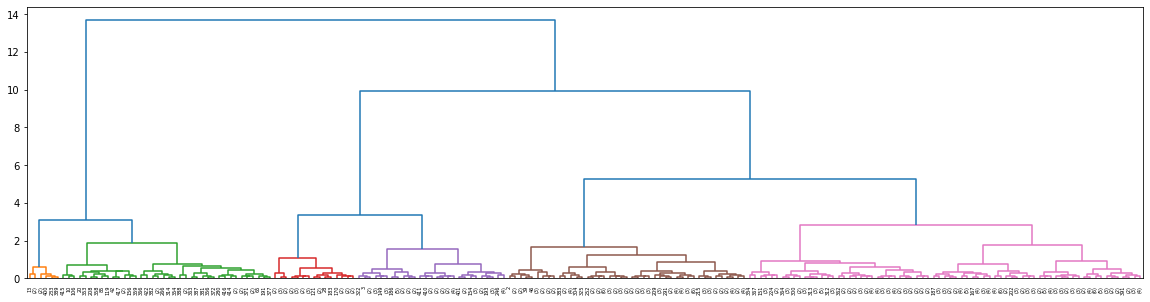

In [27]:
from scipy.cluster.hierarchy import dendrogram

fig,ax=plt.subplots(figsize=(20,5))
t = dendrogram(arbre,distance_sort="ascending",p=200,ax=ax,truncate_mode='lastp',color_threshold=3)

Différentes stratégies pour couper ...

### Effet du choix de la méthode

Pas de différence

In [28]:
from sklearn.cluster import AgglomerativeClustering

comparaison = pd.DataFrame(Xt_opendata["clusters"])

cluster = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')
comparaison["clusters_agglo"] = cluster.fit_predict(Xt_opendata[[0,1,2,3,4]])

pd.crosstab(comparaison["clusters"],comparaison["clusters_agglo"])

clusters_agglo,0,1,2,3,4
clusters,,,,,
1,0,67,0,0,0
2,0,0,127,0,0
3,175,0,0,0,0
4,0,0,0,0,15
5,0,0,0,45,0


### Fonction de consolidation spécifique à R

Recodage de la fonction

In [29]:
from sklearn.cluster import KMeans


def consolidation(X,clust,max_iter=10,**kwargs):
    """
    Apply a kmeans clustering on a MCA decomposition 
    using the centers of an hierarchical classification (HCPC)
    
    Parameters
    ----------
    X : DataFrame
        Table with the ACM dimensions and a column for the clusters
    clust : str
        Name of the cluster column
    max_inter : int
        Number of iterations
        
    Returns
    -------
    array
        New clusters with the same index
    
    """
    centers = X.groupby(clust).mean() # Calculer les centres
    km = KMeans(n_clusters = centers.shape[0], init=centers, max_iter=max_iter,**kwargs)
    new_clusters = km.fit_predict(X.drop(columns=clust))
    return new_clusters

Utilisation de la fonction

In [30]:
Xt_opendata["clusters_consolidated"] = consolidation(Xt_opendata[[0,1,2,3,4,"clusters"]],"clusters")
Xt_travail["clusters_consolidated"] = consolidation(Xt_travail[[0,1,2,"clusters"]],"clusters")

Il y a encore une petite différence avec la catégorisation de R, mais marginale. Ajout des clusters au tableau (en chaine de caractères).

In [31]:
data["classes_opendata"] = Xt_opendata["clusters_consolidated"].apply(str)
data["classes_travail"] = Xt_travail["clusters_consolidated"].apply(str)

### Passage à la visualisation

Peut-être là où il y a encore de la marge de progression avec les outils de Python, notamment pour les analyses factorielles.

#### Données opendata

Out of the box

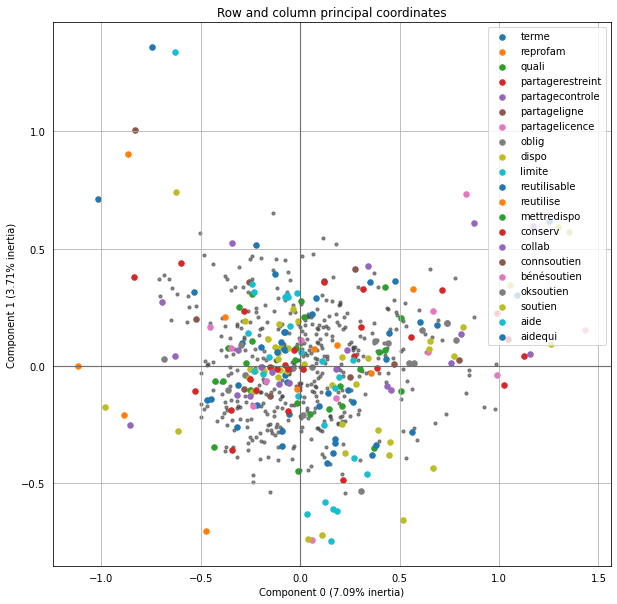

In [32]:
ax = mca1.plot_coordinates(
    X=tableau_opendata,
    ax=None,
    figsize=(10, 10),
    show_row_points=True,
    row_points_size=10,
    show_row_labels=False,
    show_column_points=True,
    column_points_size=30,
    show_column_labels=False,
    legend_n_cols=1)
#ax.get_figure().savefig('mca_coordinates_with_groups.svg')

En modifiant soi même le graphique

(-2.0, 2.0)

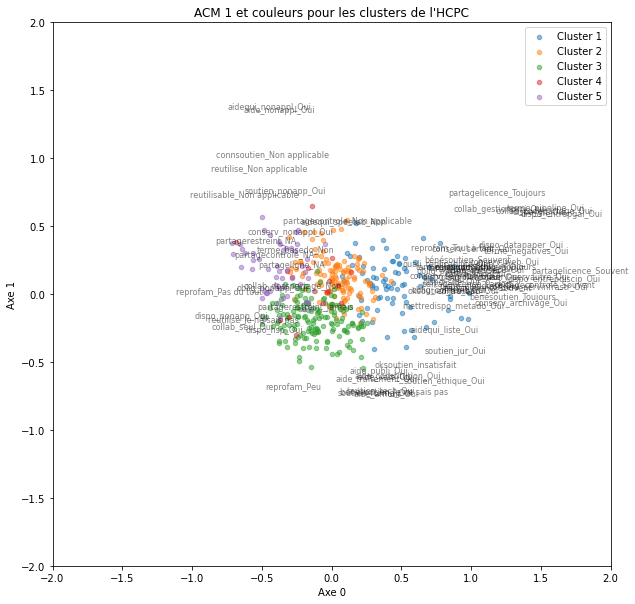

In [33]:
fig,ax = plt.subplots(figsize=(10,10))
for i,g in Xt_opendata.groupby("clusters_consolidated"):
    g.plot(kind="scatter",x=0,y=1,ax=ax,color="C%d"%i,alpha=0.5)

# Affichage des labels
for i,j in labels_opendata.iterrows():
    if abs(j[0])>0.5 or abs(j[1])>0.5:
        ax.text(j[0],j[1],i,fontsize=8,alpha=0.5)

    
plt.legend(["Cluster %d"%i for i in range(1,6)])  
ax.set_title("ACM 1 et couleurs pour les clusters de l'HCPC")
ax.set_xlabel("Axe 0")
ax.set_ylabel("Axe 1")
ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

#### Données travail

In [34]:
Xt_travail["clusters_consolidated"].value_counts()

2    293
1     84
0     52
Name: clusters_consolidated, dtype: int64

(-2.0, 2.0)

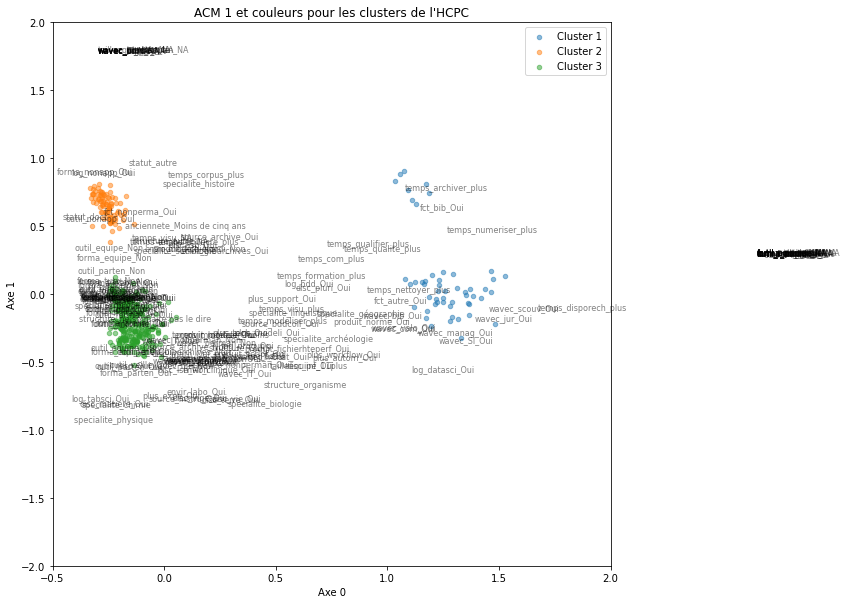

In [35]:
fig,ax = plt.subplots(figsize=(10,10))
for i,g in Xt_travail.groupby("clusters_consolidated"):
    g.plot(kind="scatter",x=0,y=1,ax=ax,color="C%d"%i,alpha=0.5)
    
for i,j in labels_travail.iterrows():
    if abs(j[0])>0.3 or abs(j[1])>0.3:
        ax.text(j[0],j[1],i,fontsize=8,alpha=0.5)

plt.legend(["Cluster %d"%i for i in range(1,4)])  
ax.set_title("ACM 1 et couleurs pour les clusters de l'HCPC")
ax.set_xlabel("Axe 0")
ax.set_ylabel("Axe 1")
ax.set_xlim(-0.5,2)
ax.set_ylim(-2,2)

Souvent : important d'aller dans le détail. Là ça dépend des traditions. Les outils ne sont pas encore complètement implémentés en Python

In [36]:
#mca1.row_coordinates(tableau_opendata)

In [37]:
#mca1.column_coordinates(tableau_opendata)

In [38]:
#mca1.col_masses_

### Description des clusters

Il reste encore quelques éléments à implémenter de CATDES DE R  (ex : The paragons (para) and the more typical individuals of each cluster)

#### Tableaux croisés

In [39]:
pyshs.tableau_croise_multiple(data,"classes_opendata", list(data.columns[5:10]),axis=1)

0            1            2  \
Variable                     Modalités                                         
envir_theoredac (p = 0.036)  Non        11 (13.6%)   20 (16.4%)    12 (7.6%)   
                             Oui        70 (86.4%)  102 (83.6%)  145 (92.4%)   
                             Total       81 (100%)   122 (100%)   157 (100%)   
terme_corpus (p = 0.000)     Non        30 (37.0%)  100 (82.0%)   28 (17.8%)   
                             Oui        51 (63.0%)   22 (18.0%)  129 (82.2%)   
                             Total       81 (100%)   122 (100%)   157 (100%)   
terme_ressources (p = 0.032) Non        43 (53.1%)   89 (73.0%)  103 (65.6%)   
                             Oui        38 (46.9%)   33 (27.0%)   54 (34.4%)   
                             Total       81 (100%)   122 (100%)   157 (100%)   
terme_valeurs (p = 0.000)    Non        70 (86.4%)   76 (62.3%)  149 (94.9%)   
                             Oui        11 (13.6%)   46 (37.7%)     8 (5.1%)   
                             Total       81 (100%)   122 (100%)   157 (100%)   
terme_sources (p = 0.000)    Non        32 (39.5%)   88 (72.1%)   40 (25.5%)   
                             Oui        49 (60.5%)   34 (27.9%)  117 (74.5%)   
                             Total       81 (100%)   122 (100%)   157 (100%)   

                                                 3           4        Total  \
Variable                     Modalités                                        
envir_theoredac (p = 0.036)  Non         5 (31.2%)   6 (11.3%)   54 (12.6%)   
                             Oui        11 (68.8%)  47 (88.7%)  375 (87.4%)   
                             Total       16 (100%)   53 (100%)   429 (100%)   
terme_corpus (p = 0.000)     Non        10 (62.5%)  17 (32.1%)  185 (43.1%)   
                             Oui         6 (37.5%)  36 (67.9%)  244 (56.9%)   
                             Total       16 (100%)   53 (100%)   429 (100%)   
terme_ressources (p = 0.032) Non        10 (62.5%)  29 (54.7%)  274 (63.9%)   
                             Oui         6 (37.5%)  24 (45.3%)  155 (36.1%)   
                             Total       16 (100%)   53 (100%)   429 (100%)   
terme_valeurs (p = 0.000)    Non        15 (93.8%)  51 (96.2%)  361 (84.1%)   
                             Oui          1 (6.2%)    2 (3.8%)   68 (15.9%)   
                             Total       16 (100%)   53 (100%)   429 (100%)   
terme_sources (p = 0.000)    Non         6 (37.5%)  12 (22.6%)  178 (41.5%)   
                             Oui        10 (62.5%)  41 (77.4%)  251 (58.5%)   
                             Total       16 (100%)   53 (100%)   429 (100%)   

                                       Distribution  
Variable                     Modalités               
envir_theoredac (p = 0.036)  Non              12.6%  
                             Oui              87.4%  
                             Total           100.0%  
terme_corpus (p = 0.000)     Non              43.1%  
                             Oui              56.9%  
                             Total           100.0%  
terme_ressources (p = 0.032) Non              63.9%  
                             Oui              36.1%  
                             Total           100.0%  
terme_valeurs (p = 0.000)    Non              84.1%  
                             Oui              15.9%  
                             Total           100.0%  
terme_sources (p = 0.000)    Non              41.5%  
                             Oui              58.5%  
                             Total           100.0%

#### Utilisation de catdes "python" 

Cela peut prendre un peu de temps

In [40]:
var_cat, var_num, mod_cat,mod_num = pyshs.catdes(data,"classes_opendata",proba = 0.01, mod=True)

In [41]:
mod_cat

Cla/Mod (n_kj/n_j)  \
                   var                                              
classes_opendata_0 collab_codepartage_Oui                   69.74   
                   collab_codepartage_Non                    7.93   
                   dispo_git_Oui                            73.53   
                   dispo_git_Non                             8.59   
                   mettredispo_doc_Oui                      33.63   
...                                                           ...   
classes_opendata_4 conserv_archivage_Non                    13.28   
                   produit_fichierhteperf_Non               13.75   
                   produit_fichierhteperf_Oui                3.45   
                   outil_colloque_Oui                        2.22   
                   forma_mooc_Non                           14.61   

                                               Mod/Cla (n_kj/n_k)  \
                   var                                              
classes_opendata_0 collab_codepartage_Oui                   65.43   
                   collab_codepartage_Non                   34.57   
                   dispo_git_Oui                            61.73   
                   dispo_git_Non                            38.27   
                   mettredispo_doc_Oui                      92.59   
...                                                           ...   
classes_opendata_4 conserv_archivage_Non                   100.00   
                   produit_fichierhteperf_Non               96.23   
                   produit_fichierhteperf_Oui                3.77   
                   outil_colloque_Oui                        1.89   
                   forma_mooc_Non                           84.91   

                                               Proportion globale (n_j/n)  \
                   var                                                      
classes_opendata_0 collab_codepartage_Oui                           17.72   
                   collab_codepartage_Non                           82.28   
                   dispo_git_Oui                                    15.85   
                   dispo_git_Non                                    84.15   
                   mettredispo_doc_Oui                              51.98   
...                                                                   ...   
classes_opendata_4 conserv_archivage_Non                            93.01   
                   produit_fichierhteperf_Non                       86.48   
                   produit_fichierhteperf_Oui                       13.52   
                   outil_colloque_Oui                               10.49   
                   forma_mooc_Non                                   71.79   

                                               Valeur test       p hyper  \
                   var                                                     
classes_opendata_0 collab_codepartage_Oui            11.19  2.228183e-29   
                   collab_codepartage_Non           -11.19  2.396757e-29   
                   dispo_git_Oui                     11.13  4.334043e-29   
                   dispo_git_Non                    -11.13  4.629258e-29   
                   mettredispo_doc_Oui                8.67  2.135351e-18   
...                                                    ...           ...   
classes_opendata_4 conserv_archivage_Non              2.40  8.233571e-03   
                   produit_fichierhteperf_Non         2.38  8.610827e-03   
                   produit_fichierhteperf_Oui        -2.38  8.610827e-03   
                   outil_colloque_Oui                -2.38  8.554184e-03   
                   forma_mooc_Non                     2.33  9.881246e-03   

                                                     p chi2  
                   var                                       
classes_opendata_0 collab_codepartage_Oui      8.617725e-36  
                   collab_codepartage_Non      8.617725e-36  
            

### Mise en forme des heatmaps

- description des classes
- tableau croisé des classes
- contruire les tableaux
- voir avec Pandas pour construire un heatmap adapté

#### Description générale

In [42]:
results = pyshs.catdes(data,"classes_opendata",proba = 0.01)
results

(                                p  df
 classes_opendata                     
 partagecontrole      4.072036e-67  16
 partageligne         2.830492e-62  16
 partagelicence       4.657152e-49  16
 partagerestreint     3.324595e-45  16
 disc_pour_ponde      1.920255e-35  12
 ...                           ...  ..
 produit_fichierordi  7.392943e-03   4
 temps_analyser       7.779560e-03   4
 terme_stat           7.815741e-03   4
 limite_habitude      7.885773e-03   4
 limite_valo          9.400149e-03   4
 
 [163 rows x 2 columns],
                      Eta 2       p-value
 classes_opendata                        
 poids             0.148666  4.935820e-14)

In [49]:
pyshs.tableau_croise_multiple(data,"classes_opendata",results[0:15].index,axis=1)

#### Construction d'une heatmap

- l'enjeu est de prendre un ensemble de variables (notamment celles qui ont la plus forte association)
- construire le tableau de l'écart à la moyenne de la distribution
- faire la heatmap

*Attention, cela ne s'affiche que quand le Notebook est exécuté.*

#### Différentiel de tableau croisé

In [132]:
variables = results[0].index[0:15]
tableau = {}
for v in list(variables):
    t,b,p = pyshs.tableau_croise(data,"classes_opendata",
                                 v,debug=True)
    t = (p - p.iloc[-1]).drop("All").T
    #if "Non" in t.index:
    #    t = t.drop("Non")
    tableau[v] = t

In [133]:
pd.concat(tableau).style.background_gradient(cmap ='viridis')

### Utilisation de catdes (Python version)

In [ ]:
data["classes_opendata"] = data["classes_opendata"].apply(str)
var_cat, var_num, mod_cat,mod_num = pyshs.catdes(data,"classes_opendata",proba = 0.001, mod=True,weight="poids")

In [61]:
mod_cat.loc["classes_opendata_4"]

,Cla/Mod (n_kj/n_j),Mod/Cla (n_kj/n_k),Proportion globale (n_j/n),Valeur test,p hyper,p chi2
var,,,,,,
aide_nonappl_Oui,47.06,60.38,15.85,8.11,2.575309e-16,2.525584e-21
aide_nonappl_Non,5.82,39.62,84.15,-8.09,2.943346e-16,2.525584e-21
soutien_nonapp_Oui,32.71,66.04,24.94,6.78,6.016475e-12,1.513023e-13
soutien_nonapp_Non,5.59,33.96,75.06,-6.78,6.016502e-12,1.513023e-13
collab_seul_Non,6.55,41.51,78.32,-6.27,1.802208e-10,3.725510e-12
...,...,...,...,...,...,...
conserv_archivage_Non,13.28,100.00,93.01,2.40,8.233571e-03,3.298278e-02
produit_fichierhteperf_Non,13.75,96.23,86.48,2.38,8.610827e-03,2.665803e-02
produit_fichierhteperf_Oui,3.45,3.77,13.52,-2.38,8.610827e-03,2.665803e-02


In [62]:
set(mod_cat.index.get_level_values(0))

{'classes_opendata_0',
 'classes_opendata_1',
 'classes_opendata_2',
 'classes_opendata_3',
 'classes_opendata_4'}

Filtrage par rapport à une condition

In [65]:
table = pd.concat({i:mod_cat.loc[i]["Valeur test"] for i in set(mod_cat.index.get_level_values(0))},
                  axis=1).applymap(lambda x: None if x<1.96 else x)

In [66]:
table.sort_values("classes_opendata_2",ascending=False)

,classes_opendata_4,classes_opendata_0,classes_opendata_1,classes_opendata_2,classes_opendata_3
var,,,,,
disc_pour_ponde_LSH,NaN,NaN,NaN,10.19,NaN
disc_lsh_Oui,NaN,NaN,NaN,9.81,NaN
quali_reproductibilite_Non,3.78,NaN,NaN,9.29,NaN
source_instru_Non,4.65,NaN,NaN,8.56,NaN
envir_labo_Non,2.93,NaN,NaN,8.49,NaN
...,...,...,...,...,...
specialite_autre,NaN,NaN,NaN,NaN,NaN
partagelicence_Non applicable,NaN,NaN,NaN,NaN,7.41
conserv_nonappl_Non,NaN,NaN,NaN,NaN,NaN


In [67]:
table.sort_values("classes_opendata_0",
    ascending=False)[0:10].style.background_gradient(cmap ='inferno')

,classes_opendata_4,classes_opendata_0,classes_opendata_1,classes_opendata_2,classes_opendata_3
var,,,,,
collab_codepartage_Oui,nan,11.190000,nan,nan,nan
dispo_git_Oui,nan,11.130000,nan,nan,nan
mettredispo_doc_Oui,nan,8.670000,nan,nan,nan
mettredispo_metado_Oui,nan,8.120000,nan,nan,nan
quali_rechouv_Oui,nan,8.010000,nan,nan,nan
produit_norme_Oui,nan,7.950000,nan,nan,nan
collab_wiki_Oui,nan,7.590000,nan,nan,nan
log_prog_Oui,nan,7.570000,3.620000,nan,nan
partagelicence_Souvent,nan,7.540000,nan,nan,nan


## Conclusion

En recodant la fonction catdes en Python et en reproduisant les étapes de HCPC, nous avons été en mesure de retrouver globalement les mêmes résultats que l'analyse en R.

Par rapport aux résultats sous R, la correction de petites erreurs de codage modifie très légèrement les résultats numériques.

Une petite différence numérique existe aussi en fonction du calcul numérique R/Python, ce qui amène à classifier différemment quelques répondants. Par contre les clusters et les corrélations de modalités conservent l'ordre.

Cette reproduction dans un autre langage a permis non seulement de se confronter aux problèmes de formalisation des règles et des démarches, mais aussi aux différences d'approches en termes de traitements.